In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave_2d/'

datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
Data = xr.open_dataset(datafilepath+datafilename)

# grid info
import mat73
grid = mat73.loadmat('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/mfiles_2d/SUNTANS_grid.mat', only_include=['Nk', 'Nx', 'Ny', 'Depth', 'INPUT']) 

Nx = grid['Nx'].astype('int')
Ny = grid['Ny'].astype('int')
Nk = grid['Nk'].astype('int')
Nc = Nx*Ny
# Depth = np.reshape(grid['Depth'].astype('int'), (Nx, Ny), order='F')
Depth = np.reshape(grid['Depth'], (Nx, Ny), order='F')

xv = np.reshape(Data.xv.data, (Nx, Ny), order='F')
yv = np.reshape(Data.yv.data, (Nx, Ny), order='F')

In [5]:
U = np.reshape(Data.Ubt.data, (len(Data.time), Nx, Ny), order='F')
V = np.reshape(Data.Vbt.data, (len(Data.time), Nx, Ny), order='F')

## Slope bathymetry & Shoaling depth

In [6]:
lambdaM2=70.1e3
l_sponge = 20e3
slope = 0.05
D0 = 600
He = 313.1
width_he2 = 26000
width_top = width_he2 - 2*(He/2)/slope
r = width_he2/2+(D0-He/2)/slope
width_base = 2*r

L=1.5*lambdaM2-width_top-(width_base-width_top)/2
W=l_sponge/2

x_c = L/2-(width_base-width_top)/4-width_top/2
y_c = W/2

In [7]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

In [8]:
x_top = L/2- D0/slope/2 #1.5*lambdaM2/2-width_top-(width_base-width_top)+width_top/2
x_bottom = x_top + D0/slope
x_shoal = x_top + depth_shoal/slope

## scale time

In [9]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
dt_ = (Data.time.data-Data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale
t_nondim_ = dt_/T_scale

# evolution of U + $\eta$

In [10]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')
Cadv = data_Cadv.Ah0.interp(time=data.time)

In [11]:
# eta_ = data_.eta[:,:,int(Ny/2)].copy()
# C_ = data_.C_int[:,:,int(Ny/2)].differentiate("time",datetime_unit="s") + Cadv
eta_ = data_.eta.copy()

In [12]:
# calculate dynamic height
data_f=xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bt_flux.nc')
# Fx_03_ = data_f.Fx_03_int[:,:,int(Ny/2)].differentiate("time",datetime_unit="s")
Fx_03_ = data_f.Fx_03_int.differentiate("time",datetime_unit="s")
del data_f

rho0 = 1000
grav = 9.81
# p_prime_height_ = Fx_03_/U[:,:,int(Ny/2)]/rho0/grav/data_.depth[:,int(Ny/2)].data
p_prime_height_ = Fx_03_/U/rho0/grav/data_.depth.data

In [30]:
# spatially filter dissipation; running mean, binsize = N
N = 10
p_prime_height_filter1 = p_prime_height_[:,:,int(Ny/2)].copy()
p_prime_height_filter2 = p_prime_height_[:,:,int(Ny/2)+62].copy()

for idx_t in range(len(data.time)):
    p_prime_height_filter1[idx_t,:] = np.convolve(p_prime_height_filter1[idx_t,:], np.ones(N)/N, 'same')
    p_prime_height_filter2[idx_t,:] = np.convolve(p_prime_height_filter2[idx_t,:], np.ones(N)/N, 'same')

In [34]:
Data

<xarray.Dataset> Size: 8GB
Dimensions:        (Nc: 114750, numsides: 4, Ne: 230543, Two: 2, Np: 115794,
                    Nk: 100, Nkw: 101, time: 226)
Coordinates:
    Nk             (Nc) int32 459kB ...
    xv             (Nc) float64 918kB 39.98 159.3 278.4 ... 7.325e+04 7.337e+04
    yv             (Nc) float64 918kB 40.0 40.0 40.0 ... 9.96e+03 9.96e+03
    xe             (Ne) float64 2MB ...
    ye             (Ne) float64 2MB ...
  * time           (time) datetime64[ns] 2kB 2013-01-01T12:00:08 ... 2013-01-...
Dimensions without coordinates: Nc, numsides, Ne, Two, Np, Nkw
Data variables: (12/61)
    suntans_mesh   int32 4B ...
    cells          (Nc, numsides) int32 2MB ...
    nfaces         (Nc) int32 459kB ...
    face           (Nc, numsides) int32 2MB ...
    edges          (Ne, Two) int32 2MB ...
    neigh          (Nc, numsides) int32 2MB ...
    ...             ...
    Fx_prime5_int  (time, Nc) float64 207MB ...
    Fy_prime1_int  (time, Nc) float64 207MB ...
    Fy_prime2_int  (time, Nc) float64 207MB ...
    Fy_prime3_int  (time, Nc) float64 207MB ...
    Fy_prime4_int  (time, Nc) float64 207MB ...
    Fy_prime5_int  (time, Nc) float64 207MB ...
Attributes:
    title:    SUNTANS NetCDF output file

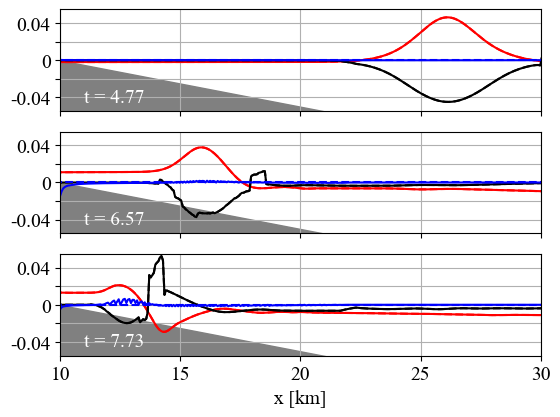

In [62]:
count = 0
fig, ax1 = plt.subplots(nrows=3, ncols=1, figsize=(6.2,1.5*3))
for idx_t_data in [37, 51, 60]: 
    ax1[count].plot(data.x.data, eta_[idx_t_data,:,int(Ny/2)].data, color='r', label=r'$\eta_C$ [m]')
    ax1[count].plot(data.x.data, eta_[idx_t_data,:,int(Ny/2)+62].data, linestyle='--', color='r', label=r'$\eta_N$ [m]')
    # ax1[count].plot(data.x.data, p_prime_height_[idx_t_data,:,int(Ny/2)].data, color='k', label=r"$\langle p'_C\rangle/\rho_0 H$")
    # ax1[count].plot(data.x.data, p_prime_height_[idx_t_data,:,int(Ny/2)+62].data, linestyle='--', color='k', label=r"$\langle p'_N\rangle/\rho_0 H$")
    ax1[count].plot(data.x.data, p_prime_height_filter1[idx_t_data,:].data, color='k', label=r"$\langle p'_C\rangle/\rho_0 H$")
    ax1[count].plot(data.x.data, p_prime_height_filter2[idx_t_data,:].data, linestyle='--', color='k', label=r"$\langle p'_N\rangle/\rho_0 H$")

    ax1[count].plot(data.x.data, U[idx_t_data,:,int(Ny/2)], c='b', linestyle='-', label=r'U$_C$ [ms$^{-1}$]')
    ax1[count].plot(data.x.data, V[idx_t_data,:,int(Ny/2)+62], c='b', linestyle='--', label=r'V$_N$ [ms$^{-1}$]')
        
    ax1[count].set_xlim([x_c+10000,x_c+30000])
    ax1[count].set_xticks(np.arange(x_c+10000,x_c+30000+1,5000))
    # ax1[count].set_ylim([-.1, .1])
    ax1[count].set_ylim([-.055, .055])
    ax1[count].set_yticks(np.arange(-.04,.05,.02))      
    ax1[count].set_yticklabels(['-0.04', '', '0', '', '0.04'])
    ax1[count].grid(True)
    ax1[count].fill_between(data.x.data, -data_.depth[:,int(Ny/2)].data*1e-4, np.zeros(data.x.data.shape)-600*1e-4, color='.5')
    if count == 2:
        ax1[count].set_xticklabels(['10', '15', '20', '25', '30'])
        # ax1[count].legend(ncol=1, loc='right',frameon=False, fontsize=11)
        ax1[count].set_xlabel(r'x [km]', fontsize=14)
    else:
        ax1[count].set_xticklabels(['', '', '', '', ''])   
    ax1[count].text(x_c+11000,-.045, f"t = {np.round(t_nondim[idx_t_data],2)}", fontsize=14, color='w')#.026
    ax1[count].set_ylabel('')
    ax1[count].tick_params(axis='both', which='major', labelsize=14)
    plt.rcParams["font.family"] = "Times New Roman"
    count += 1

# ax1[-1].legend(bbox_to_anchor=(1.05, 1.6), loc='upper left') 
# fig.tight_layout()
plt.savefig(outfilepath+ f"U_V_eta_p_prime_slice_summer_nof_2d.png", transparent=True, dpi=300)


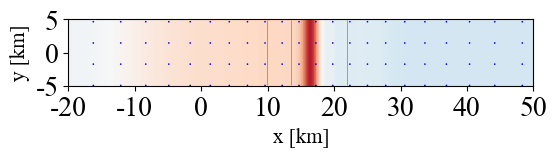

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,2))

idx_t_data = 50
ax.pcolormesh(data.x.data, data.y.data, eta_[idx_t_data,:,:].data.T, vmax=.05, vmin=-.05, cmap=cm.RdBu_r)
Q = ax.quiver(data.x.data[::40], data.y.data[::40], (U[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, (V[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, scale=.5e2, scale_units='inches', width=4e-3, color='b')
if idx_t_data == 39: #42:
    qk = ax.quiverkey(Q, 0.1, 1.03, 1e1, r'10 m$^2$s$^{-1}$', labelpos='E', fontproperties={'size':18}, labelcolor='b')
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='.5', linewidths=.5)
ax.set_xlim([x_c-20000, x_c+50000])
ax.set_ylim([y_c-5000, y_c+5000])
ax.set_xticks(np.arange(x_c-20000,x_c+50000+1,10000))
ax.set_yticks(np.arange(y_c-5000,y_c+5000+1,5000))
ax.set_xticklabels(['-20', '-10', '0', '10', '20', '30','40','50'])
ax.set_yticklabels(['-5','0', '5'])
ax.set_xlabel('x [km]', fontsize=15)
ax.set_ylabel('y [km]', fontsize=15)
ax.set_title(f'')
ax.set_aspect('equal')
# ax.text(x_c-18000, y_c-4500, f"t = {np.round(t_nondim[idx_t_data],2)}", fontsize=20, color='k')#.026

ax.tick_params(axis='both', which='major', labelsize=20)
plt.rcParams["font.family"] = "Times New Roman"

plt.savefig(outfilepath+ f"UVeta_overhead_summer_nof_2d.png", transparent = True, dpi=300)

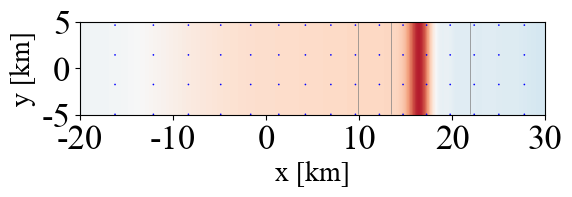

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,2.5))

idx_t_data = 50
ax.pcolormesh(data.x.data, data.y.data, eta_[idx_t_data,:,:].data.T, vmax=.05, vmin=-.05, cmap=cm.RdBu_r)
Q = ax.quiver(data.x.data[::40], data.y.data[::40], (U[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, (V[idx_t_data,::40,::40]*data_.depth[::40,::40].data).T, scale=.5e2, scale_units='inches', width=4e-3, color='b')
if idx_t_data == 39: #42:
    qk = ax.quiverkey(Q, 0.1, 1.03, 1e1, r'10 m$^2$s$^{-1}$', labelpos='E', fontproperties={'size':18}, labelcolor='b')
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='.5', linewidths=.5)
ax.set_xlim([x_c-20000, x_c+30000])
ax.set_ylim([y_c-5000, y_c+5000])
ax.set_xticks(np.arange(x_c-20000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-5000,y_c+5000+1,5000))
ax.set_xticklabels(['-20', '-10', '0', '10', '20', '30'])
ax.set_yticklabels(['-5','0', '5'])
ax.set_xlabel('x [km]', fontsize=20)
ax.set_ylabel('y [km]', fontsize=20)
ax.set_title(f'')
ax.set_aspect('equal')
# ax.text(x_c-18000, y_c-4500, f"t = {np.round(t_nondim[idx_t_data],2)}", fontsize=20, color='k')#.026

ax.tick_params(axis='both', which='major', labelsize=25)
plt.rcParams["font.family"] = "Times New Roman"

plt.savefig(outfilepath+ f"UVeta_overhead_summer_nof_2d.png", transparent = True, dpi=300)